In [ ]:
!pip install -q ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
bank_marketing = fetch_ucirepo(id=222)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
X = bank_marketing.data.features
y = bank_marketing.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.columns.tolist())

Features shape: (45211, 16)
Target shape: (45211, 1)

Feature columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Target column:
['y']


In [ ]:
df = pd.concat([X, y], axis=1)

print("Complete dataset shape:", df.shape)

display(df.head())

Complete dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
display(df.head(10))

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
5,35,management,married,tertiary,no,231,yes,no,NaN,5,may,139,1,-1,0,NaN,no
6,28,management,single,tertiary,no,447,yes,yes,NaN,5,may,217,1,-1,0,NaN,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,NaN,5,may,380,1,-1,0,NaN,no
8,58,retired,married,primary,no,121,yes,no,NaN,5,may,50,1,-1,0,NaN,no
9,43,technician,single,secondary,no,593,yes,no,NaN,5,may,55,1,-1,0,NaN,no


In [ ]:
display(df.tail(10))

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
45201,53,management,married,tertiary,no,583,no,no,cellular,17,nov,226,1,184,4,success,yes
45202,34,admin.,single,secondary,no,557,no,no,cellular,17,nov,224,1,-1,0,NaN,yes
45203,23,student,single,tertiary,no,113,no,no,cellular,17,nov,266,1,-1,0,NaN,yes
45204,73,retired,married,secondary,no,2850,no,no,cellular,17,nov,300,1,40,8,failure,yes
45205,25,technician,single,secondary,no,505,no,yes,cellular,17,nov,386,2,-1,0,NaN,yes
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45211
Number of columns: 17


In [ ]:
print("Columns in the dataset:")

for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

Columns in the dataset:
1 : age
2 : job
3 : marital
4 : education
5 : default
6 : balance
7 : housing
8 : loan
9 : contact
10 : day_of_week
11 : month
12 : duration
13 : campaign
14 : pdays
15 : previous
16 : poutcome
17 : y


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

print("Missing-value percentage:")
print(missing_percentage)

Missing-value percentage:
age             0.00
job             0.64
marital         0.00
education       4.11
default         0.00
balance         0.00
housing         0.00
loan            0.00
contact        28.80
day_of_week     0.00
month           0.00
duration        0.00
campaign        0.00
pdays           0.00
previous        0.00
poutcome       81.75
y               0.00
dtype: float64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(45211, 17)


In [ ]:
print("Target column:", y.columns[0])

Target column: y


In [ ]:
target_column = y.columns[0]

print("Target values:")
print(df[target_column].value_counts())

Target values:
y
no     39922
yes     5289
Name: count, dtype: int64


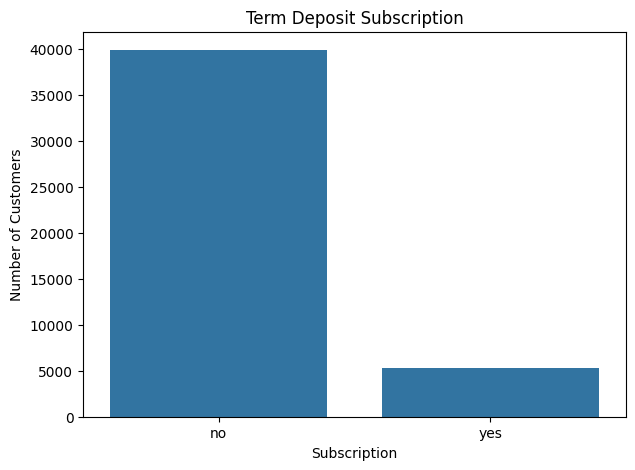

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target_column
)

plt.title("Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
target_percentage = (
    df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Target percentage:")
print(target_percentage)

Target percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [ ]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [ ]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [ ]:
display(
    df.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,44923,11,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,43354,3,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,32191,2,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


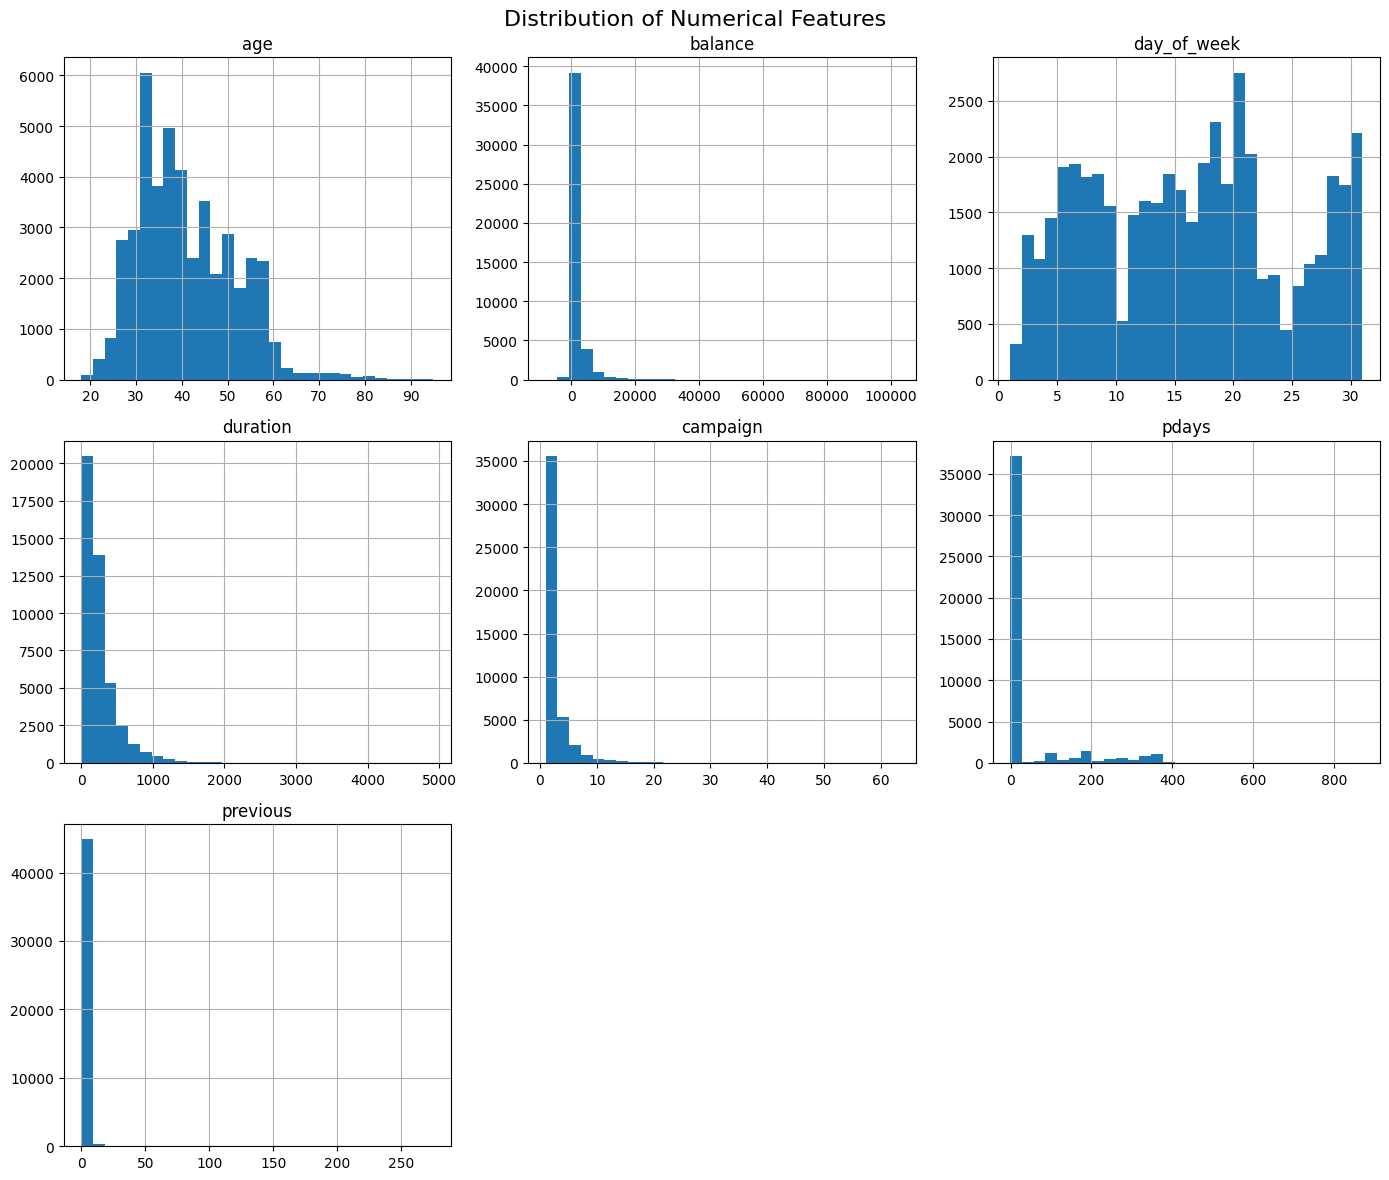

In [ ]:
df[numeric_columns].hist(
    figsize=(14, 12),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

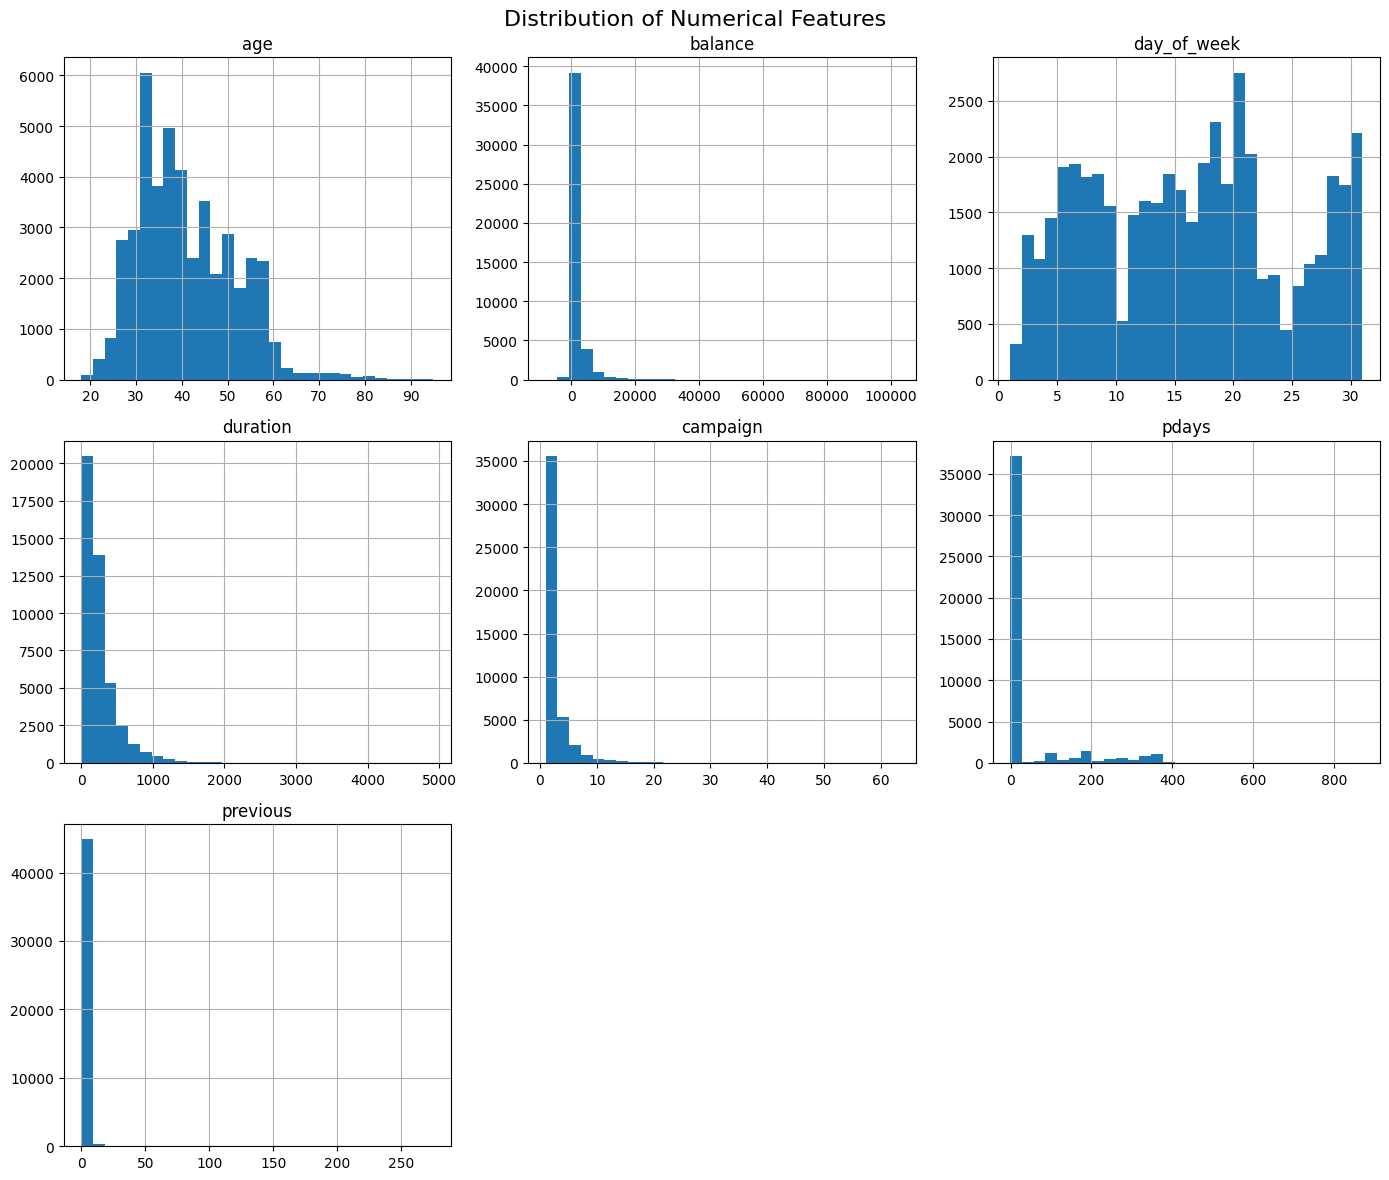

In [ ]:
df[numeric_columns].hist(
    figsize=(14, 12),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

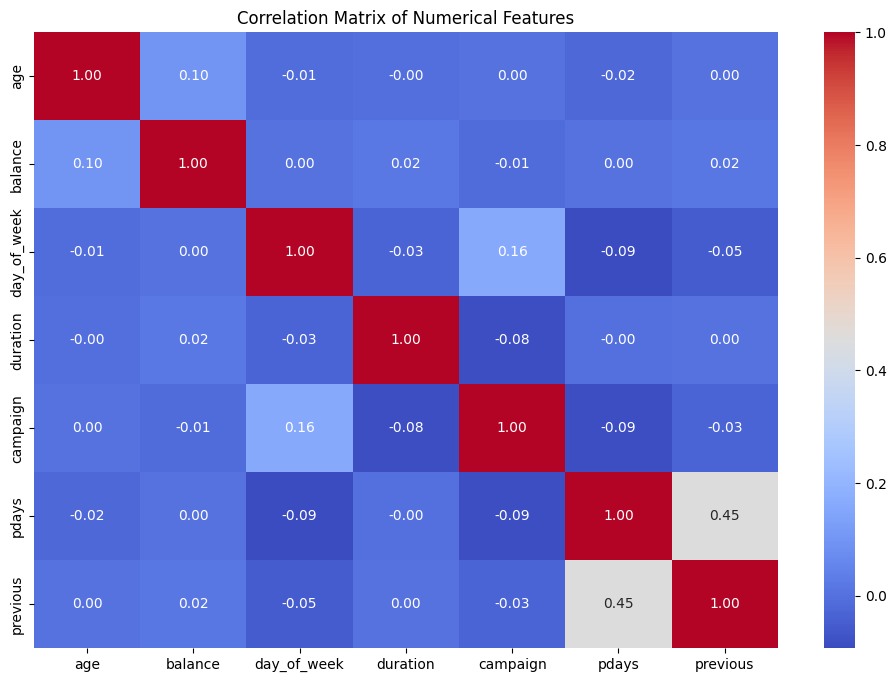

In [ ]:
plt.figure(figsize=(12, 8))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

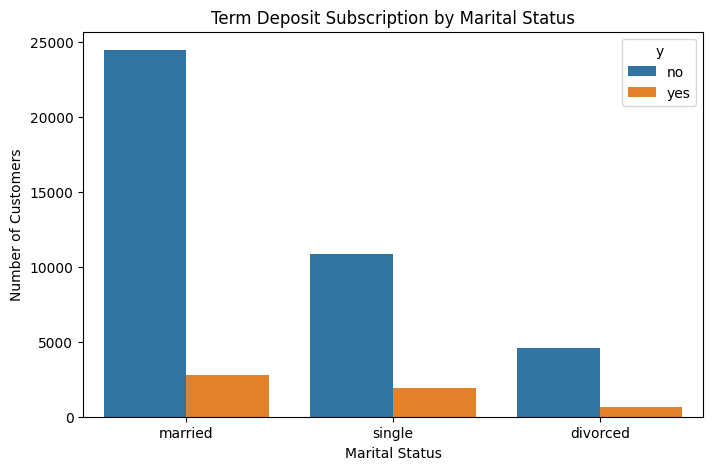

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="marital",
    hue=target_column
)

plt.title("Term Deposit Subscription by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.show()

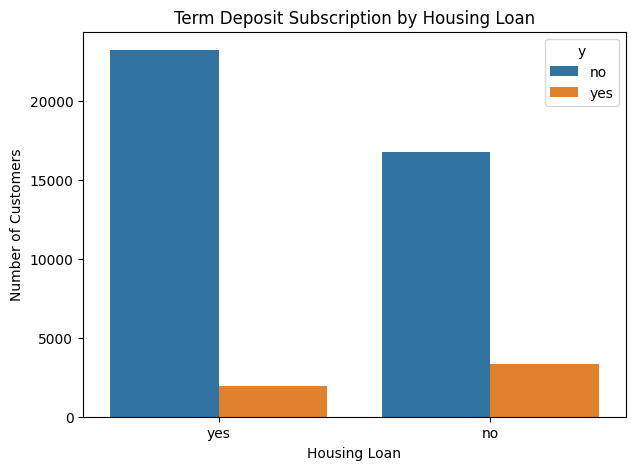

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="housing",
    hue=target_column
)

plt.title("Term Deposit Subscription by Housing Loan")
plt.xlabel("Housing Loan")
plt.ylabel("Number of Customers")

plt.show()

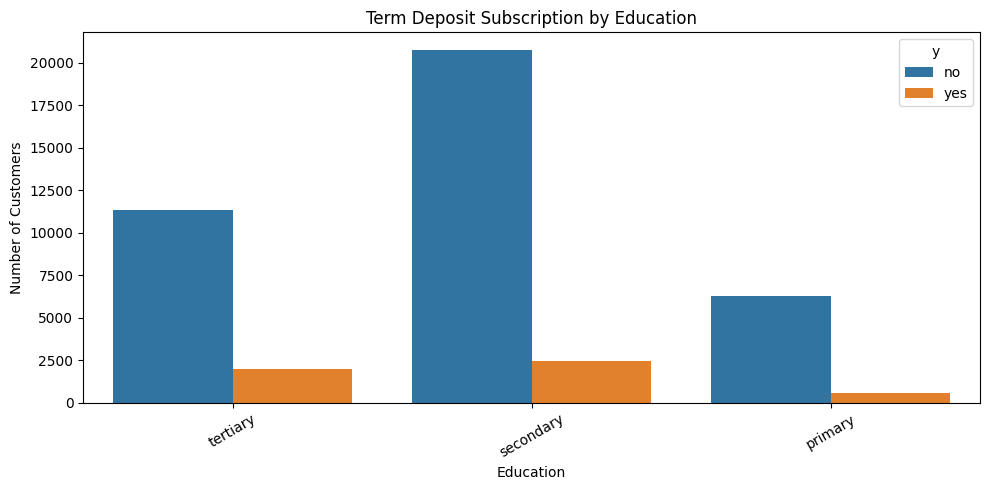

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="education",
    hue=target_column
)

plt.title("Term Deposit Subscription by Education")
plt.xlabel("Education")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

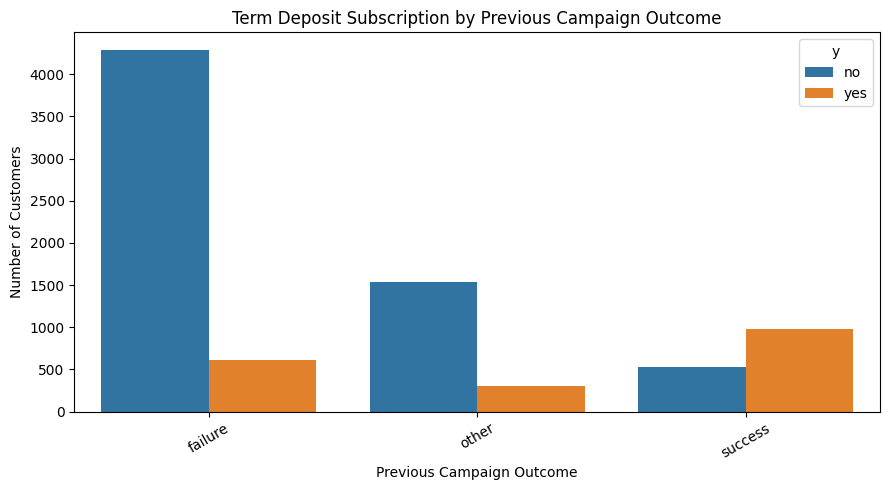

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="poutcome",
    hue=target_column
)

plt.title("Term Deposit Subscription by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.copy()

for column in df_clean.select_dtypes(
    include=["object", "category"]
).columns:

    df_clean[column] = (
        df_clean[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

print("Categorical values standardized.")

Categorical values standardized.


In [ ]:
for column in df_clean.select_dtypes(
    include=["object", "category"]
).columns:

    print("\n" + "=" * 50)
    print(column)
    print("=" * 50)
    print(df_clean[column].value_counts().head(20))


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
nan               288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
nan           1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
nan          13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

In [ ]:
df_clean["target"] = (
    df_clean[target_column]
    .map({
        "no": 0,
        "yes": 1
    })
)

print(df_clean["target"].value_counts())

target
0    39922
1     5289
Name: count, dtype: int64


In [ ]:
print("Target encoding:")
print("0 = No subscription")
print("1 = Yes subscription")

print("\nEncoded target:")
print(df_clean["target"].value_counts())

Target encoding:
0 = No subscription
1 = Yes subscription

Encoded target:
target
0    39922
1     5289
Name: count, dtype: int64


In [ ]:
df_clean = df_clean.drop(
    columns=[target_column]
)

print("New dataset shape:", df_clean.shape)

New dataset shape: (45211, 17)


In [ ]:
X = df_clean.drop(
    columns=["target"]
)

y = df_clean["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (45211, 16)
y shape: (45211,)

Features:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 36168
Testing samples : 9043

Training target distribution:
target
0    31937
1     4231
Name: count, dtype: int64

Testing target distribution:
target
0    7985
1    1058
Name: count, dtype: int64


In [ ]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [ ]:
logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred = logistic_model.predict(
    X_test
)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
y_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

print("First 20 prediction probabilities:")
print(y_prob[:20])

First 20 prediction probabilities:
[0.00736831 0.01075221 0.01939182 0.00499568 0.04176722 0.03366544
 0.01820607 0.97440758 0.03634885 0.04040348 0.00300649 0.03694786
 0.076532   0.00768698 0.13486543 0.03957923 0.04990674 0.02301642
 0.45723068 0.0036682 ]


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9012
Accuracy: 90.12%


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision:.4f}")

Precision: 0.6445


In [ ]:
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Recall: {recall:.4f}")

Recall: 0.3478


In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"F1-score: {f1:.4f}")

F1-score: 0.4518


In [ ]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9056


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Subscription",
            "Subscription"
        ],
        zero_division=0
    )
)

                 precision    recall  f1-score   support

No Subscription       0.92      0.97      0.95      7985
   Subscription       0.64      0.35      0.45      1058

       accuracy                           0.90      9043
      macro avg       0.78      0.66      0.70      9043
   weighted avg       0.89      0.90      0.89      9043



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7782  203]
 [ 690  368]]


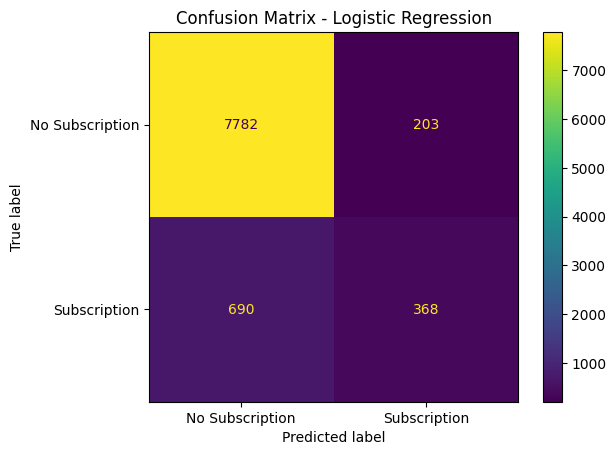

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Subscription",
        "Subscription"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.show()

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

print("ROC curve calculated successfully.")

ROC curve calculated successfully.


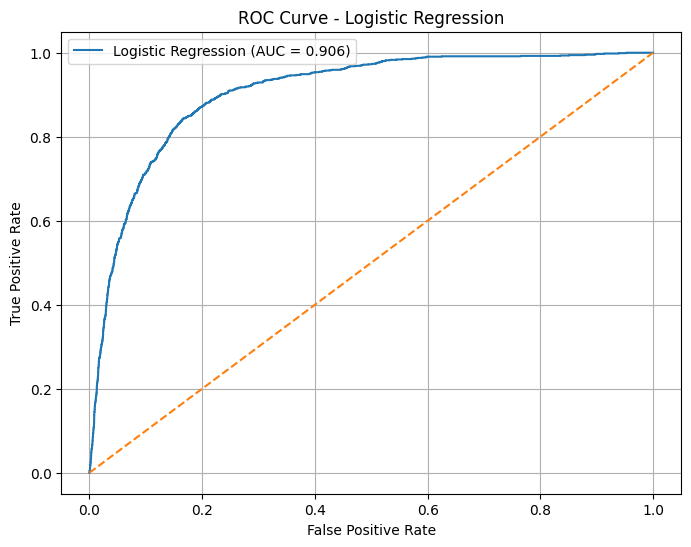

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
})

display(
    comparison_df.head(20)
)

,Actual,Predicted,Probability
0,0,0,0.007368
1,0,0,0.010752
2,0,0,0.019392
3,0,0,0.004996
4,0,0,0.041767
5,0,0,0.033665
6,0,0,0.018206
7,1,1,0.974408
8,0,0,0.036349
9,0,0,0.040403


In [ ]:
results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results_df["Score"] = results_df["Score"].round(4)

display(results_df)

,Metric,Score
0,Accuracy,0.9012
1,Precision,0.6445
2,Recall,0.3478
3,F1-score,0.4518
4,ROC-AUC,0.9056


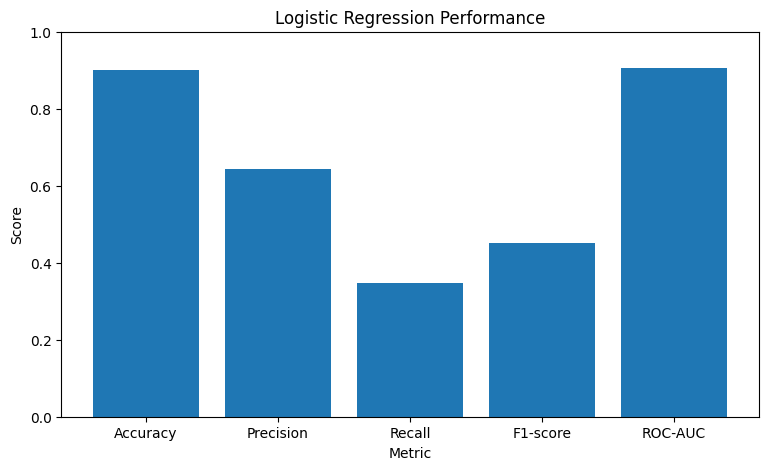

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Metric"],
    results_df["Score"]
)

plt.ylim(0, 1)

plt.title(
    "Logistic Regression Performance"
)

plt.xlabel("Metric")
plt.ylabel("Score")

plt.show()

In [ ]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of processed features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of processed features: 51

First 20 features:
['num__age' 'num__balance' 'num__day_of_week' 'num__duration'
 'num__campaign' 'num__pdays' 'num__previous' 'cat__job_admin.'
 'cat__job_blue-collar' 'cat__job_entrepreneur' 'cat__job_housemaid'
 'cat__job_management' 'cat__job_nan' 'cat__job_retired'
 'cat__job_self-employed' 'cat__job_services' 'cat__job_student'
 'cat__job_technician' 'cat__job_unemployed' 'cat__marital_divorced']


In [ ]:
coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(
    coefficient_df.head(20)
)

,Feature,Coefficient,Absolute_Coefficient
50,cat__poutcome_success,1.549282,1.549282
42,cat__month_mar,1.457573,1.457573
39,cat__month_jan,-1.321511,1.321511
33,cat__contact_nan,-1.201578,1.201578
3,num__duration,1.091874,1.091874
44,cat__month_nov,-0.927599,0.927599
40,cat__month_jul,-0.883044,0.883044
46,cat__month_sep,0.816278,0.816278
47,cat__poutcome_failure,-0.792804,0.792804
48,cat__poutcome_nan,-0.778145,0.778145


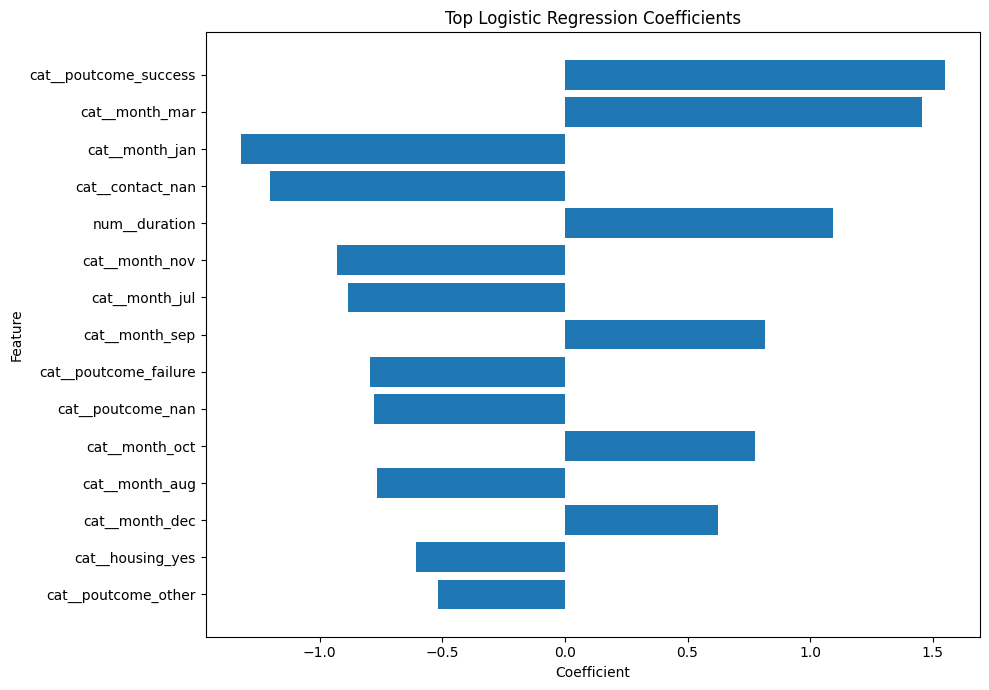

In [ ]:
top_coefficients = coefficient_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients["Feature"][::-1],
    top_coefficients["Coefficient"][::-1]
)

plt.title(
    "Top Logistic Regression Coefficients"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
import os

problem2_dir = (
    "/content/drive/MyDrive/NN/Problem_Set_02"
)

os.makedirs(
    problem2_dir,
    exist_ok=True
)

print("Folder created:")
print(problem2_dir)

Folder created:
/content/drive/MyDrive/NN/Problem_Set_02


In [ ]:
import joblib

model_path = os.path.join(
    problem2_dir,
    "bank_marketing_logistic_regression.pkl"
)

joblib.dump(
    logistic_model,
    model_path
)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
/content/drive/MyDrive/NN/Problem_Set_02/bank_marketing_logistic_regression.pkl


In [ ]:
import json

results = {
    "model": "Logistic Regression",
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc)
}

results_path = os.path.join(
    problem2_dir,
    "results.json"
)

with open(
    results_path,
    "w"
) as f:
    json.dump(
        results,
        f,
        indent=4
    )

print("Results saved to:")
print(results_path)

print("\nResults:")
print(
    json.dumps(
        results,
        indent=4
    )
)

Results saved to:
/content/drive/MyDrive/NN/Problem_Set_02/results.json

Results:
{
    "model": "Logistic Regression",
    "accuracy": 0.901249585314608,
    "precision": 0.6444833625218914,
    "recall": 0.34782608695652173,
    "f1_score": 0.4518109269490485,
    "roc_auc": 0.9055740146044154
}


In [ ]:
processed_path = os.path.join(
    problem2_dir,
    "processed_bank_marketing.csv"
)

df_clean.to_csv(
    processed_path,
    index=False
)

print("Processed dataset saved to:")
print(processed_path)

Processed dataset saved to:
/content/drive/MyDrive/NN/Problem_Set_02/processed_bank_marketing.csv


In [ ]:
sample_customer = X_test.iloc[[0]].copy()

print("Sample customer:")
display(sample_customer)

Sample customer:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
1392,40,blue-collar,married,primary,no,640,yes,yes,nan,8,may,347,2,-1,0,nan


In [ ]:
sample_prediction = logistic_model.predict(
    sample_customer
)[0]

sample_probability = logistic_model.predict_proba(
    sample_customer
)[0][1]

if sample_prediction == 1:
    prediction_text = "YES - Customer will subscribe"
else:
    prediction_text = "NO - Customer will not subscribe"

print("Prediction:", prediction_text)
print(
    f"Subscription probability: {sample_probability:.2%}"
)

Prediction: NO - Customer will not subscribe
Subscription probability: 0.74%
